In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch.nn as nn
from fastai.vision.all import *
from fastai.losses import CrossEntropyLossFlat
from fastai.metrics import RocAuc

print("Input folder:", os.listdir("../input"))



/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Input folder: ['sample_submission.csv', 'description.md', 'test.zip', 'train.csv', 'sample_submission.csv.zip', 'test', 'train.zip', 'aerial-cactus-identification', 'train', 'train.csv.zip']


In [2]:
path = Path("../input")



In [3]:
train_df = pd.read_csv(path / "train.csv")
# keep labels as integers (0/1) for classification
train_df["has_cactus"] = train_df["has_cactus"].astype(int)

sample_sub = pd.read_csv(path / "sample_submission.csv")
print("Train shape:", train_df.shape)
print("Sample submission shape:", sample_sub.shape)



Train shape: (14175, 2)
Sample submission shape: (3325, 2)


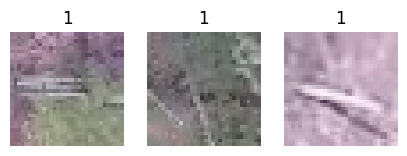

In [4]:
dls = ImageDataLoaders.from_df(
    df=train_df,
    path=path / "train",  # folder with training images
    fn_col="id",  # image filename column
    label_col="has_cactus",  # target column (int 0/1)
    y_block=CategoryBlock(),  # categorical block for binary classification
    valid_pct=0.2,
    seed=42,
    item_tfms=Resize(32),
    batch_tfms=aug_transforms(
        do_flip=True,
        flip_vert=True,
        max_rotate=10.0,
        max_zoom=1.1,
        max_lighting=0.2,
        max_warp=0.2,
        p_affine=0.75,
        p_lighting=0.75,
    ),
    bs=64,
)

dls.show_batch(max_n=3, figsize=(5, 6))



/usr/local/lib/python3.11/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 115MB/s]


Suggested LR: 5.75e-03


epoch,train_loss,valid_loss,roc_auc_score,time


ValueError: Exception occured in `Recorder` when calling event `after_validate`:
	y should be a 1d array, got an array of shape (2835, 2) instead.

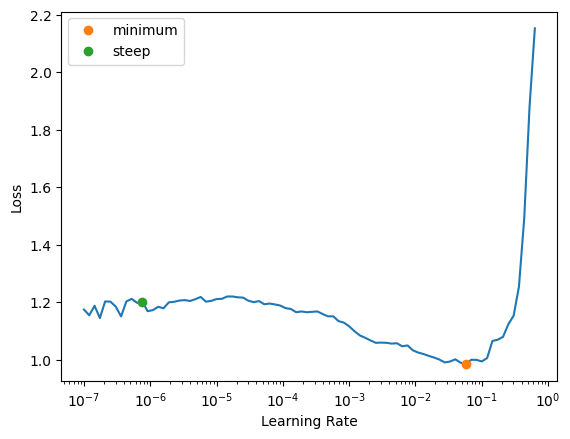

In [5]:
learn = cnn_learner(
    dls,
    resnet50,
    loss_func=CrossEntropyLossFlat(),
    metrics=RocAuc(),
    model_dir="./model",
)

lr_min, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))
print(f"Suggested LR: {lr_min:.2e}")

learn.fit_one_cycle(10, lr_max=lr_min)



In [6]:
test_path = path / "test"  # folder containing test images
rows = []

for img_name in sample_sub["id"]:
    img = PILImage.create(test_path / img_name)
    _, _, probs = learn.predict(img)
    # probability for class '1' (has cactus)
    prob_cactus = probs[1].item()
    rows.append({"id": img_name, "has_cactus": prob_cactus})

submission = pd.DataFrame(rows, columns=["id", "has_cactus"])
submission.to_csv("submission.csv", index=False)
print("Submission saved to submission.csv, rows:", submission.shape[0])

Submission saved to submission.csv, rows: 3325
